['Rf_1s12' 'Rf_2p12' 'Rf_2p32' 'Rf_2s12' 'Rf_3d32' 'Rf_3d52' 'Rf_3p12'
 'Rf_3p32' 'Rf_3s12' 'Rf_4d32' 'Rf_4d52' 'Rf_4f52' 'Rf_4f72' 'Rf_4p12'
 'Rf_4p32' 'Rf_4s12' 'Rf_5d32' 'Rf_5d52' 'Rf_5f52' 'Rf_5f72' 'Rf_5p12'
 'Rf_5p32' 'Rf_5s12' 'Rf_6d32' 'Rf_6p12' 'Rf_6p32' 'Rf_6s12' 'Rf_7s12']

Rf_1s12
              r         P             Q
0  1.117395e-08  0.000102 -3.047121e-09
1  1.225426e-08  0.000111 -3.664148e-09
2  1.343898e-08  0.000122 -4.406278e-09
3  1.473827e-08  0.000134 -5.298895e-09
4  1.616315e-08  0.000147 -6.372460e-09
5  1.772575e-08  0.000161 -7.663642e-09
6  1.943945e-08  0.000177 -9.216599e-09
7  2.131880e-08  0.000194 -1.108432e-08
            r             P             Q
190  0.187708  6.996222e-07 -2.965563e-07
191  0.199982  2.113944e-07 -8.848548e-08
192  0.212924  5.967585e-08 -2.457592e-08
193  0.226561  1.569331e-08 -6.327382e-09
194  0.240919  3.832821e-09 -1.502971e-09
195  0.256025  8.666012e-10 -3.275197e-10
196  0.271907  1.807777e-10 -1.431369e-10
197  0.288

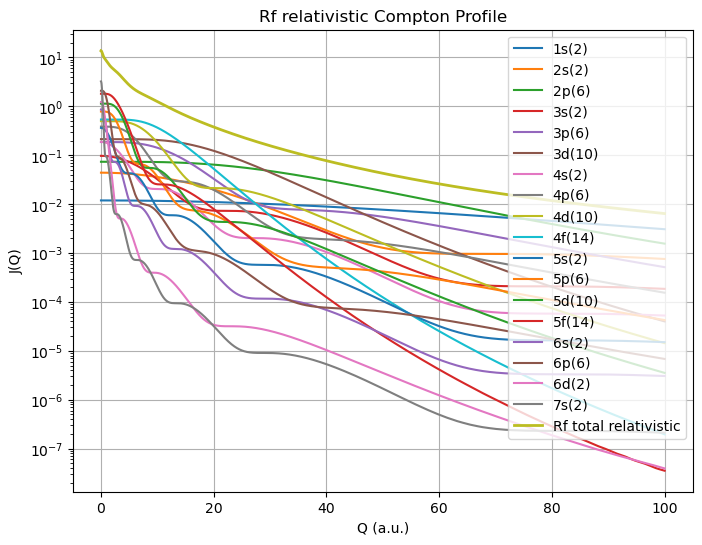

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn
from scipy.integrate import cumulative_trapezoid

csv_file = "/root/geant4/fac/Rf_all_wavefunctions.csv"
df = pd.read_csv(csv_file)
df = df.dropna(subset=["r", "P", "Q"])

p = np.arange(0.0, 300.0 + 0.05, 0.05)
Qgrid = np.arange(0.0, 100.0 + 0.05, 0.05)

print(df["Orbital"].unique())


def get_orbital(df, name, print_values=True):
    d = df[df["Orbital"] == name].copy()
    d = d.sort_values("r")

    r_raw = d["r"].to_numpy()
    P_raw = d["P"].to_numpy()
    Q_raw = d["Q"].to_numpy()

    if print_values:
        print("\n======================")
        print(name)
        print("======================")
        print(d[["r", "P", "Q"]].head(8))
        print(d[["r", "P", "Q"]].tail(8))

    raw_norm = np.trapezoid(P_raw**2 + Q_raw**2, r_raw)
    print(name, "raw radial norm ∫(P²+Q²)dr =", raw_norm)

    # normalize raw FAC P,Q
    P_raw = P_raw / np.sqrt(raw_norm)
    Q_raw = Q_raw / np.sqrt(raw_norm)

    # interpolate to finer r grid
    r = np.linspace(r_raw.min(), r_raw.max(), 5000)
    P = np.interp(r, r_raw, P_raw)
    Qs = np.interp(r, r_raw, Q_raw)

    fine_norm = np.trapezoid(P**2 + Qs**2, r)
    P = P / np.sqrt(fine_norm)
    Qs = Qs / np.sqrt(fine_norm)

    print(name, "fine radial norm after interpolation =", np.trapezoid(P**2 + Qs**2, r))

    return r, P, Qs
   # return r_raw, P_raw, Q_raw

def chi_transform(p_grid, r, radial, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r)

        # FAC P = rG, Q = rF
        # chi = sqrt(2/pi) int P(r) j_l(pr) r dr
        val = np.sqrt(2/np.pi) * np.trapezoid(radial * jl * r, r)

        chi.append(val)

    return np.array(chi)


def calculate_J(p_grid, chiG, chiF, Qgrid):
    integrand = (chiG**2 + chiF**2) * p_grid

    rev = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev[::-1]
    J_Q = np.interp(Qgrid, p_grid, J_p)

    return J_Q


def one_orbital_J(df, name, l_large, l_small):
    r, P, Qs = get_orbital(df, name)

    chiG = chi_transform(p, r, P, l_large)
    chiF = chi_transform(p, r, Qs, l_small)

    I = (chiG**2 + chiF**2) * p**2
    print(name, "momentum norm ∫I(p)dp =", np.trapezoid(I, p))

    J = calculate_J(p, chiG, chiF, Qgrid)
    print(name, "Compton check 2∫J(Q)dQ =", 2*np.trapezoid(J, Qgrid))

    return J


# =====================================================
# Relativistic orbitals
# large component l = orbital l
# small component l' is decided by j
# =====================================================

J_1s12 = one_orbital_J(df, "Rf_1s12", 0, 1)

J_2s12 = one_orbital_J(df, "Rf_2s12", 0, 1)
J_2p12 = one_orbital_J(df, "Rf_2p12", 1, 0)
J_2p32 = one_orbital_J(df, "Rf_2p32", 1, 2)

J_3s12 = one_orbital_J(df, "Rf_3s12", 0, 1)
J_3p12 = one_orbital_J(df, "Rf_3p12", 1, 0)
J_3p32 = one_orbital_J(df, "Rf_3p32", 1, 2)
J_3d32 = one_orbital_J(df, "Rf_3d32", 2, 1)
J_3d52 = one_orbital_J(df, "Rf_3d52", 2, 3)

J_4s12 = one_orbital_J(df, "Rf_4s12", 0, 1)
J_4p12 = one_orbital_J(df, "Rf_4p12", 1, 0)
J_4p32 = one_orbital_J(df, "Rf_4p32", 1, 2)
J_4d32 = one_orbital_J(df, "Rf_4d32", 2, 1)
J_4d52 = one_orbital_J(df, "Rf_4d52", 2, 3)
J_4f52 = one_orbital_J(df, "Rf_4f52", 3, 2)
J_4f72 = one_orbital_J(df, "Rf_4f72", 3, 4)

J_5s12 = one_orbital_J(df, "Rf_5s12", 0, 1)
J_5p12 = one_orbital_J(df, "Rf_5p12", 1, 0)
J_5p32 = one_orbital_J(df, "Rf_5p32", 1, 2)
J_5d32 = one_orbital_J(df, "Rf_5d32", 2, 1)
J_5d52 = one_orbital_J(df, "Rf_5d52", 2, 3)
J_5f52 = one_orbital_J(df, "Rf_5f52", 3, 2)
J_5f72 = one_orbital_J(df, "Rf_5f72", 3, 4)

J_6s12 = one_orbital_J(df, "Rf_6s12", 0, 1)
J_6p12 = one_orbital_J(df, "Rf_6p12", 1, 0)
J_6p32 = one_orbital_J(df, "Rf_6p32", 1, 2)
J_6d32 = one_orbital_J(df, "Rf_6d32", 2, 1)

J_7s12 = one_orbital_J(df, "Rf_7s12", 0, 1)

J_total_Rf_rel = (
    2*J_1s12
    + 2*J_2s12
    + 2*J_2p12 + 4*J_2p32
    + 2*J_3s12
    + 2*J_3p12 + 4*J_3p32
    + 4*J_3d32 + 6*J_3d52
    + 2*J_4s12
    + 2*J_4p12 + 4*J_4p32
    + 4*J_4d32 + 6*J_4d52
    + 6*J_4f52 + 8*J_4f72
    + 2*J_5s12
    + 2*J_5p12 + 4*J_5p32
    + 4*J_5d32 + 6*J_5d52
    + 6*J_5f52 + 8*J_5f72
    + 2*J_6s12
    + 2*J_6p12 + 4*J_6p32
    + 2*J_6d32
    + 2*J_7s12 
       )

print("\nTotal Rf check 2∫Jtotal dQ =", 2*np.trapezoid(J_total_Rf_rel, Qgrid))
print("Expected close to 104")


table = pd.DataFrame({
    "Q": Qgrid,
    "J_1s1/2(2)": J_1s12,
    "J_2s1/2(2)": J_2s12,
    "J_2p1/2(2)": J_2p12,
    "J_2p3/2(4)": J_2p32,
    "J_3s1/2(2)": J_3s12,
    "J_3p1/2(2)": J_3p12,
    "J_3p3/2(4)": J_3p32,
    "J_3d3/2(4)": J_3d32,
    "J_3d5/2(6)": J_3d52,
    "J_4s1/2(2)": J_4s12,
    "J_4p1/2(2)": J_4p12,
    "J_4p3/2(4)": J_4p32,
    "J_4d3/2(4)": J_4d32,
    "J_4d5/2(6)": J_4d52,
    "J_4f5/2(6)": J_4f52,
    "J_4f7/2(8)": J_4f72,
    "J_5s1/2(2)": J_5s12,
    "J_5p1/2(2)": J_5p12,
    "J_5p3/2(4)": J_5p32,
    "J_5d3/2(4)": J_5d32,
    "J_5d5/2(6)": J_5d52,
    "J_5f5/2(6)": J_5f52,
    "J_5f7/2(8)": J_5f72,
    "J_6s1/2(2)": J_6s12,
    "J_6p1/2(2)": J_6p12,
    "J_6p3/2(4)": J_6p32,
    "J_6d3/2(2)": J_6d32,
    "J_7s1/2(2)": J_7s12,
    "J_total_Rf_relativistic": J_total_Rf_rel
})

table.to_csv("Rf_relativistic_Compton_profile.csv", index=False)
print(table)


plt.figure(figsize=(8,6))
plt.plot(Qgrid, 2*J_1s12, label="1s(2)")
plt.plot(Qgrid, 2*J_2s12, label="2s(2)")
plt.plot(Qgrid, 2*J_2p12 + 4*J_2p32, label="2p(6)")
plt.plot(Qgrid, 2*J_3s12, label="3s(2)")
plt.plot(Qgrid, 2*J_3p12 + 4*J_3p32, label="3p(6)")
plt.plot(Qgrid, 4*J_3d32 + 6*J_3d52, label="3d(10)")
plt.plot(Qgrid, 2*J_4s12, label="4s(2)")
plt.plot(Qgrid, 2*J_4p12 + 4*J_4p32, label="4p(6)")
plt.plot(Qgrid, 4*J_4d32 + 6*J_4d52, label="4d(10)")
plt.plot(Qgrid, 6*J_4f52 + 8*J_4f72, label="4f(14)")
plt.plot(Qgrid, 2*J_5s12, label="5s(2)")
plt.plot(Qgrid, 2*J_5p12 + 4*J_5p32, label="5p(6)")
plt.plot(Qgrid, 4*J_5d32 + 6*J_5d52, label="5d(10)")
plt.plot(Qgrid, 6*J_5f52 + 8*J_5f72, label="5f(14)")
plt.plot(Qgrid, 2*J_6s12, label="6s(2)")
plt.plot(Qgrid, 2*J_6p12 + 4*J_6p32, label="6p(6)")
plt.plot(Qgrid, 2*J_6d32, label="6d(2)")
plt.plot(Qgrid, 2*J_7s12, label="7s(2)")
plt.plot(Qgrid, J_total_Rf_rel, label="Rf total relativistic", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Rf relativistic Compton Profile")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()